In [ ]:
total_survey_sample = """ 
SELECT COUNT(DISTINCT(UserID)) Total
FROM Answer
"""
total_num = pd.read_sql(total_survey_sample, connection)
total_num

,Total
0,4218


There were 4218 total survey participants.

Participant distribution according to year: 

[Text(0.5, 1.0, 'Survey Participants According to Year')]

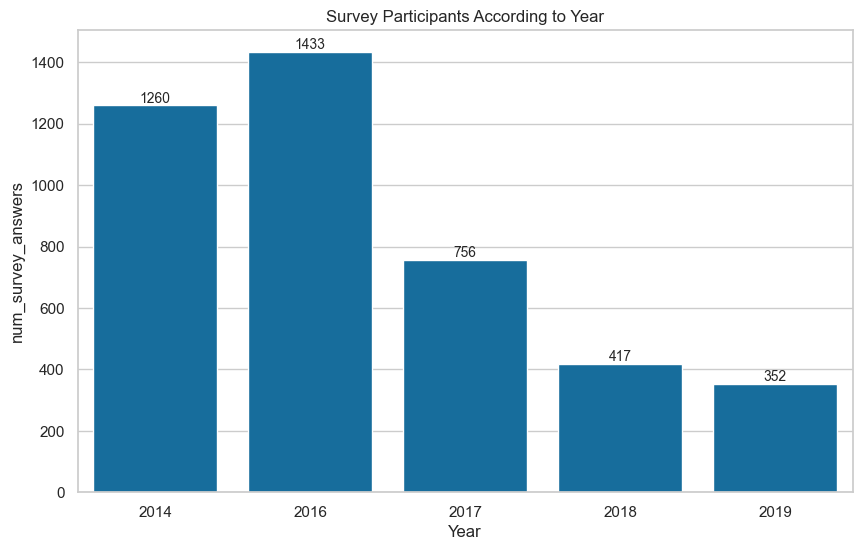

In [ ]:
ax = sns.barplot(num_survey_year, x="Year", y="num_survey_answers")
ax.bar_label(ax.containers[0], fontsize=10)
ax.set(title="Survey Participants According to Year")

Mostly male or female participants.

Gender according to year: 

In [ ]:
pd.reset_option("max_rows")
q = """ 
SELECT SurveyID Year, COUNT(SurveyID) Frequency,
CASE WHEN AnswerText LIKE 'Female' THEN 'Female'
WHEN AnswerText LIKE '%Female-identified%' THEN 'Female'
WHEN AnswerText LIKE '%Woman-identified%' THEN 'Female'
WHEN AnswerText LIKE 'female' THEN 'Female' 
WHEN AnswerText LIKE 'MALE' THEN 'Male'
WHEN AnswerText LIKE '%Male%' THEN 'Male' 
WHEN AnswerText LIKE 'Masculine' THEN 'Male'  
WHEN AnswerText LIKE 'Ostensibly Male' THEN 'Male' 
WHEN AnswerText LIKE 'male' THEN 'Male'
Else 'Other' END AS Gender
FROM Answer
WHERE QuestionID = 2
GROUP BY 1, 3
"""
gender = pd.read_sql(q, connection)
gender.head()

,Year,Frequency,Gender
0,2014,247,Female
1,2014,998,Male
2,2014,15,Other
3,2016,336,Female
4,2016,1064,Male


[Text(0.5, 1.0, 'Gender per Year')]

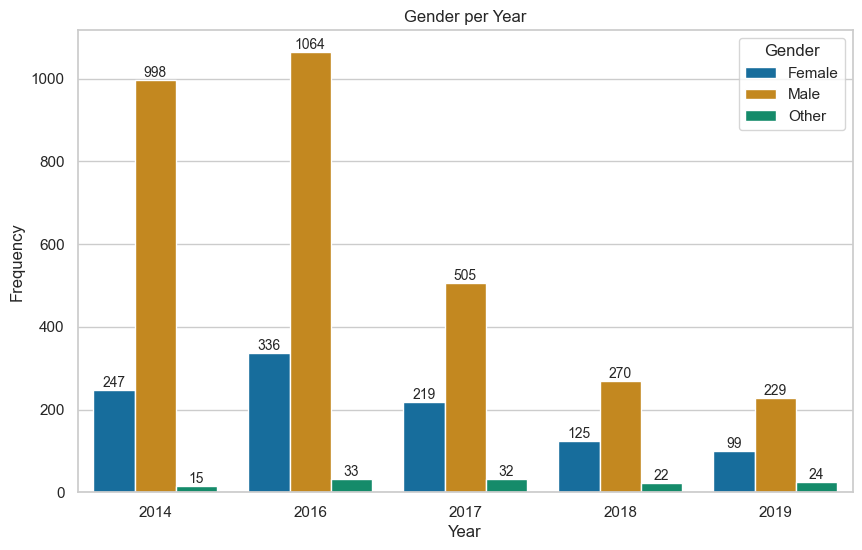

In [ ]:
ax = sns.barplot(gender, x="Year", y="Frequency", hue="Gender")
ax.bar_label(ax.containers[2], fontsize=10)
ax.bar_label(ax.containers[0], fontsize=10)
ax.bar_label(ax.containers[1], fontsize=10)
ax.set(title="Gender per Year")


In [ ]:
q = """ 
WITH t1 AS (SELECT CASE WHEN AnswerText LIKE 'United States' THEN 'United States of America' 
WHEN AnswerText LIKE 'United States of America' THEN 'United States of America' 
WHEN AnswerText = -1 THEN 'Other'
ELSE AnswerText END AS home_country
FROM Answer
WHERE QuestionID = 3)

SELECT home_country, COUNT(home_country) home_country_frequency
FROM t1
GROUP BY 1
ORDER BY 2 DESC
"""
home_country = pd.read_sql(q, connection)
home_country.head()


,home_country,home_country_frequency
0,United States of America,2604
1,United Kingdom,482
2,Canada,199
3,Germany,136
4,Netherlands,98


In [ ]:
q = """ 
SELECT AnswerText work_country, COUNT(AnswerText) work_country_frequency
FROM Answer
WHERE QuestionID = 50
GROUP BY AnswerText
ORDER BY 2 DESC
LIMIT 10
"""
work_country = pd.read_sql(q, connection)
work_country

,work_country,work_country_frequency
0,United States of America,1872
1,United Kingdom,300
2,Canada,122
3,Germany,90
4,Netherlands,70
5,Australia,50
6,India,39
7,France,34
8,Brazil,30
9,Spain,24


Top 3 work countries: United States of America, United Kingdom, and Canada. 

Total number of participants for these three countries: 1872+300+122=2294

Looking at the frequency for home and work countries:

In [ ]:
total_participants_USA_UK_Canada = 2294

[Text(0.5, 1.0, 'Age Frequency')]

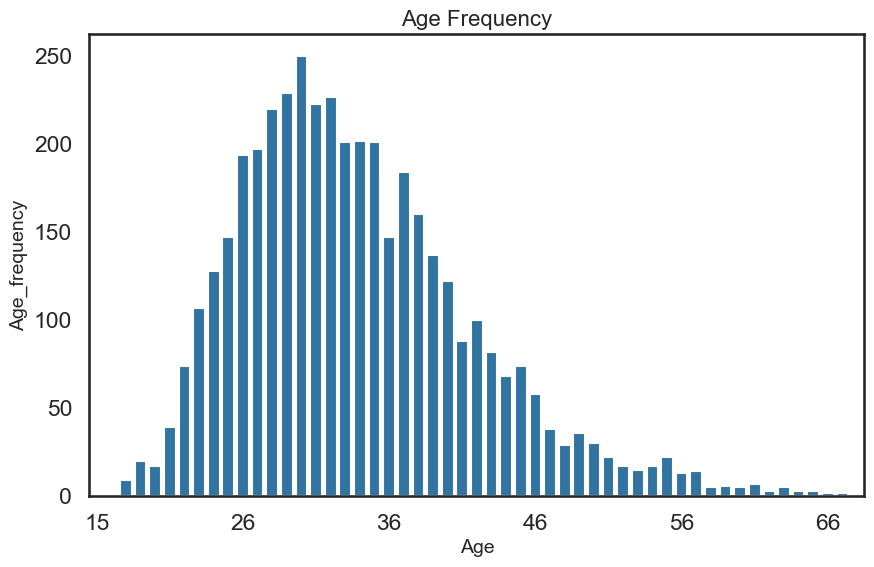

In [ ]:
age = age.drop(age[(age.Age < 15)].index)
age = age.drop(age[(age.Age > 70)].index)
ax = sns.barplot(age, x="Age", y="Age_frequency")
for ind, label in enumerate(ax.get_xticklabels()):
    if ind % 10 == 0: 
        label.set_visible(True)
    else:
        label.set_visible(False)

ax.set(title="Age Frequency")

[Text(0.5, 1.0, 'Tech role or not According to Gender')]

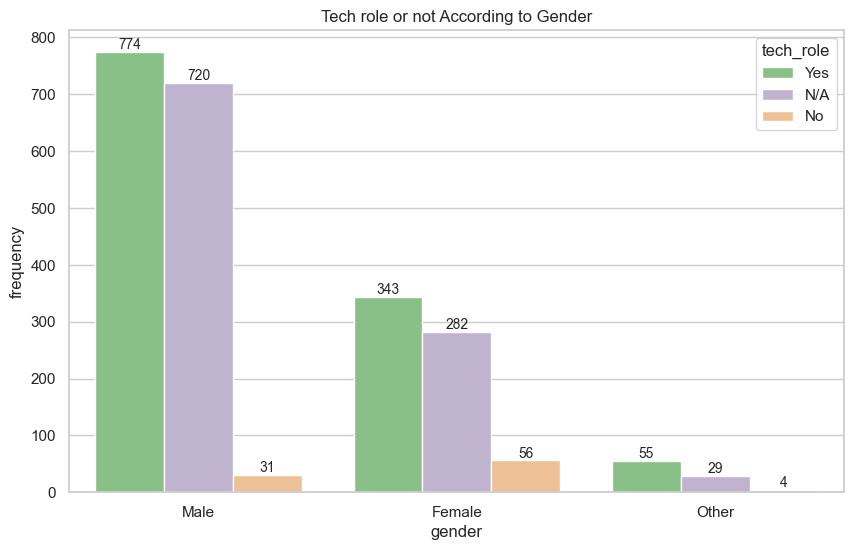

In [ ]:
q = """ 
WITH t1 AS (
    SELECT SurveyID, UserID, AnswerText,
    CASE WHEN AnswerText LIKE 'Female' THEN 'Female'
    WHEN AnswerText LIKE '%Female-identified%' THEN 'Female'
    WHEN AnswerText LIKE '%Woman-identified%' THEN 'Female'
    WHEN AnswerText LIKE 'female' THEN 'Female' 
    WHEN AnswerText LIKE 'MALE' THEN 'Male'
    WHEN AnswerText LIKE '%Male%' THEN 'Male' 
    WHEN AnswerText LIKE 'Masculine' THEN 'Male'  
    WHEN AnswerText LIKE 'Ostensibly Male' THEN 'Male' 
    WHEN AnswerText LIKE 'male' THEN 'Male'  
    Else 'Other' END AS gender
    FROM Answer
    WHERE QuestionID = 2), 

t2 AS (
    SELECT UserID, AnswerText work_country
    FROM Answer
    WHERE QuestionID = 50), 

t3 AS (
    SELECT UserID, CASE WHEN AnswerText = 1 THEN 'Yes' 
    WHEN AnswerText = 0 THEN 'No' 
    Else 'N/A' END AS tech_role
    FROM Answer
    WHERE QuestionID = 13)

SELECT t1.gender, t3.tech_role, COUNT(t1.gender) frequency
FROM t1
JOIN t2
ON t1.UserID = t2.UserID
JOIN t3
ON t2.UserID = t3.UserID
WHERE (t2.work_country LIKE 'United States of America' OR t2.work_country LIKE 'United Kingdom' OR t2.work_country LIKE 'Canada')
GROUP BY 1, 2
ORDER BY frequency DESC
"""
c = pd.read_sql(q, connection)
sns.color_palette('Accent')

ax = sns.barplot(c, x="gender", y="frequency", hue="tech_role", palette='Accent')
ax.bar_label(ax.containers[0], fontsize=10)
ax.bar_label(ax.containers[1], fontsize=10)
ax.bar_label(ax.containers[2], fontsize=10)

ax.set(title="Tech role or not According to Gender")

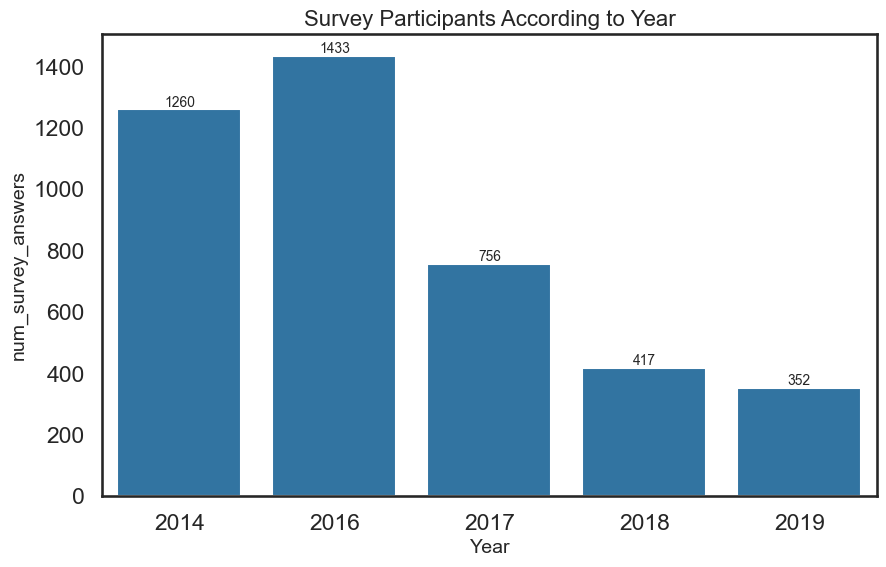

In [ ]:
survey_sample_year = """ 
SELECT SurveyID Year, COUNT(DISTINCT(UserID)) num_survey_answers
FROM Answer
GROUP BY SurveyID
"""
num_survey_year = pd.read_sql(survey_sample_year, connection)
ax = sns.barplot(num_survey_year, x="Year", y="num_survey_answers");
ax.bar_label(ax.containers[0], fontsize=10);
ax.set(title="Survey Participants According to Year");

In [ ]:
def question_missing_stats(question_id: int, total: int) -> pd.DataFrame:
    """
    Return missing counts and percentages for one survey question.
    Missing = -1, empty string, space, or NaN in AnswerText.
    """
    q = f"""
        SELECT UserID, AnswerText
        FROM Answer
        WHERE QuestionID = {question_id}
    """
    df = pd.read_sql(q, connection)
    s = df["AnswerText"].astype(str).str.strip()
    missing = s.isin(["-1", "", " "]) | s.isna()
    n_answers = len(df)
    n_missing = int(missing.sum())

    return pd.DataFrame(
        {
            "question_id": [question_id],
            "n_answers": [n_answers],
            "n_missing": [n_missing],
            "pct_missing": [(n_missing / total) * 100],
        }
    )


In [ ]:
q = """ 
SELECT CASE WHEN AnswerText = -1 THEN 'N/A'
WHEN AnswerText LIKE 'I prefer not to answer' THEN 'N/A' 
ELSE AnswerText END AS race, COUNT(AnswerText) race_frequency
FROM Answer
WHERE QuestionID = 89
GROUP BY 1
ORDER BY 2 DESC
"""
race = pd.read_sql(q, connection)

In [ ]:
q = """ 
SELECT AnswerText position, COUNT(AnswerText) frequency
FROM Answer
WHERE QuestionID = 117
GROUP BY AnswerText
ORDER BY 2 DESC
"""
position = pd.read_sql(q, connection)


,position,frequency
0,Back-end Developer,737
1,Front-end Developer,502
2,DevOps/SysAdmin,282
3,Supervisor/Team Lead,277
4,Other,187
5,Support,168
6,One-person shop,161
7,Designer,135
8,Executive Leadership,101
9,Dev Evangelist/Advocate,99


In [ ]:
q = """ 
SELECT COUNT(AnswerText) frequency,  CASE WHEN AnswerText = 1 THEN 'Yes' 
WHEN AnswerText = 0 THEN 'No' 
ELSE 'N/A' END AS tech_role
FROM Answer
WHERE QuestionID = 13
GROUP BY AnswerText
ORDER BY 2 DESC
"""
tech_role = pd.read_sql(q, connection)
tech_role = tech_role.assign(Percent = lambda x: x.frequency / total_participants * 100)
#tech_role

,frequency,tech_role,Percent
0,1471,Yes,34.874348
1,100,No,2.370792
2,1387,N/A,32.882883


[Text(0.5, 1.0, 'Mental Health Benefits From Employer According to Gender')]

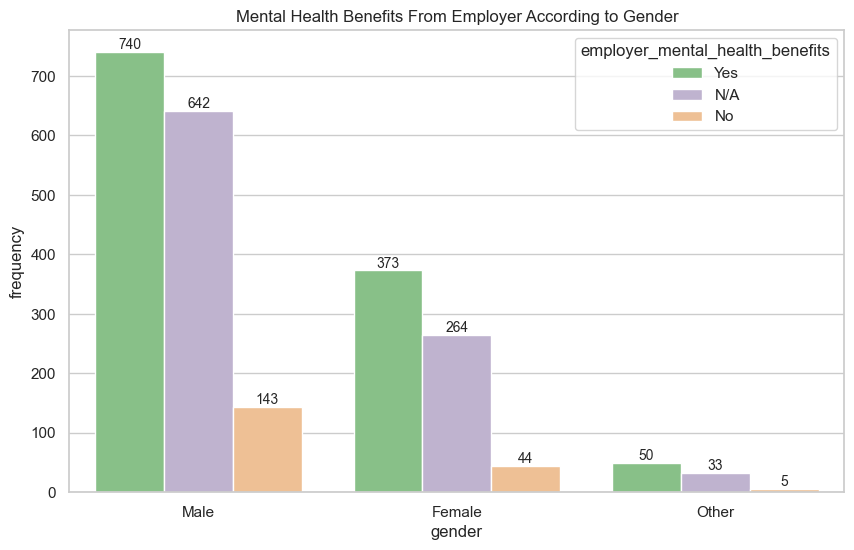

In [ ]:
q = """ 
WITH t1 AS (
    SELECT SurveyID, UserID, AnswerText,
    CASE WHEN AnswerText LIKE 'Female' THEN 'Female'
    WHEN AnswerText LIKE '%Female-identified%' THEN 'Female'
    WHEN AnswerText LIKE '%Woman-identified%' THEN 'Female'
    WHEN AnswerText LIKE 'female' THEN 'Female' 
    WHEN AnswerText LIKE 'MALE' THEN 'Male'
    WHEN AnswerText LIKE '%Male%' THEN 'Male' 
    WHEN AnswerText LIKE 'Masculine' THEN 'Male'  
    WHEN AnswerText LIKE 'Ostensibly Male' THEN 'Male' 
    WHEN AnswerText LIKE 'male' THEN 'Male'  
    Else 'Other' END AS gender
    FROM Answer
    WHERE QuestionID = 2), 

t2 AS (
    SELECT UserID, AnswerText work_country
    FROM Answer
    WHERE QuestionID = 50), 

t3 AS (
    SELECT UserID, CASE WHEN AnswerText = -1 THEN 'N/A' 
    WHEN AnswerText LIKE '%know' THEN 'N/A'
    WHEN AnswerText LIKE 'Not eligible for coverage / NA' THEN 'N/A' 
    ELSE AnswerText END AS employer_mental_health_benefits
    FROM Answer
    WHERE QuestionID = 10)

SELECT t1.gender gender, t3.employer_mental_health_benefits, COUNT(t1.gender) frequency
FROM t1
JOIN t2
ON t1.UserID = t2.UserID
JOIN t3
ON t2.UserID = t3.UserID
WHERE (t2.work_country LIKE 'United States of America' OR t2.work_country LIKE 'United Kingdom' OR t2.work_country LIKE 'Canada')
GROUP BY 1, 2
ORDER BY frequency DESC
"""
c = pd.read_sql(q, connection)

sns.color_palette('Accent')
ax = sns.barplot(c, x="gender", y="frequency", hue="employer_mental_health_benefits", palette='Accent')
ax.bar_label(ax.containers[0], fontsize=10)
ax.bar_label(ax.containers[1], fontsize=10)
ax.bar_label(ax.containers[2], fontsize=10)

ax.set(title="Mental Health Benefits From Employer According to Gender")

In [ ]:
q = """ 
WITH t1 AS (SELECT CASE WHEN AnswerText = -1 THEN 'N/A'
WHEN AnswerText LIKE 'I am not sure' THEN 'N/A' 
ELSE AnswerText END AS insurance_options_mental_health
FROM Answer
WHERE QuestionID = 14)

SELECT insurance_options_mental_health, COUNT(insurance_options_mental_health) frequency
FROM t1
GROUP BY 1
ORDER BY 2 DESC
"""
options_care = pd.read_sql(q, connection)
options_care

,insurance_options_mental_health,frequency
0,N/A,1119
1,No,970
2,Yes,869


[Text(0.5, 1.0, 'Work Country and Family History')]

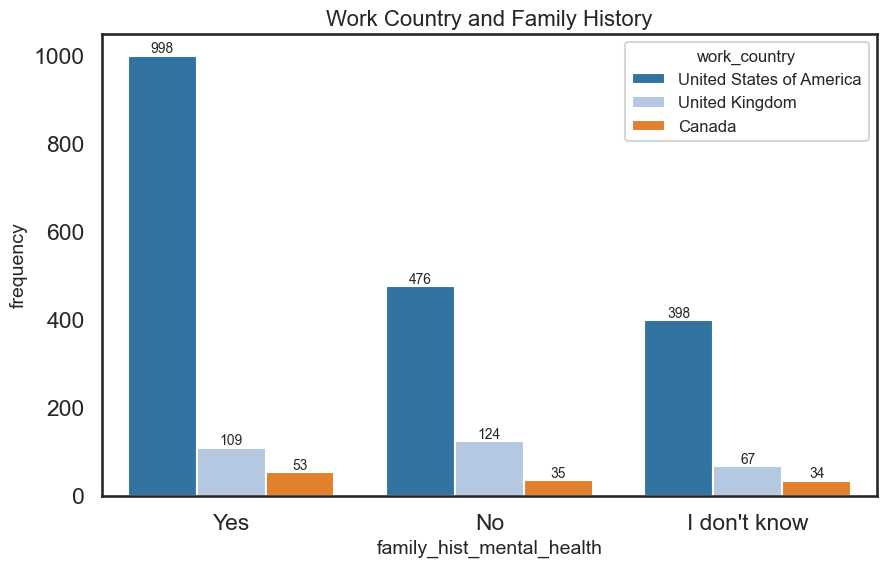

In [ ]:
q = """ 
WITH t1 AS (
    SELECT SurveyID, UserID, AnswerText,
    CASE WHEN AnswerText LIKE 'Female' THEN 'Female'
    WHEN AnswerText LIKE '%Female-identified%' THEN 'Female'
    WHEN AnswerText LIKE '%Woman-identified%' THEN 'Female'
    WHEN AnswerText LIKE 'female' THEN 'Female' 
    WHEN AnswerText LIKE 'MALE' THEN 'Male'
    WHEN AnswerText LIKE '%Male%' THEN 'Male' 
    WHEN AnswerText LIKE 'Masculine' THEN 'Male'  
    WHEN AnswerText LIKE 'Ostensibly Male' THEN 'Male' 
    WHEN AnswerText LIKE 'male' THEN 'Male'  
    Else 'Other' END AS gender
    FROM Answer
    WHERE QuestionID = 2), 

t2 AS (
    SELECT UserID, AnswerText work_country
    FROM Answer
    WHERE QuestionID = 50), 

t3 AS (
    SELECT UserID, AnswerText
    FROM Answer
    WHERE QuestionID = 6)

SELECT t2.work_country, t3.AnswerText family_hist_mental_health, COUNT(t2.work_country) frequency
FROM t1
JOIN t2
ON t1.UserID = t2.UserID
JOIN t3
ON t2.UserID = t3.UserID
WHERE (t2.work_country LIKE 'United States of America' OR t2.work_country LIKE 'United Kingdom' OR t2.work_country LIKE 'Canada')
GROUP BY 1, 2
ORDER BY frequency DESC
"""
c = pd.read_sql(q, connection)

sns.color_palette('tab20')
ax = sns.barplot(c, x="family_hist_mental_health", y="frequency", hue="work_country", palette='tab20')
ax.bar_label(ax.containers[0], fontsize=10)
ax.bar_label(ax.containers[1], fontsize=10)
ax.bar_label(ax.containers[2], fontsize=10)
ax.set(title="Work Country and Family History")

[Text(0.5, 1.0, 'Mental Health Family History')]

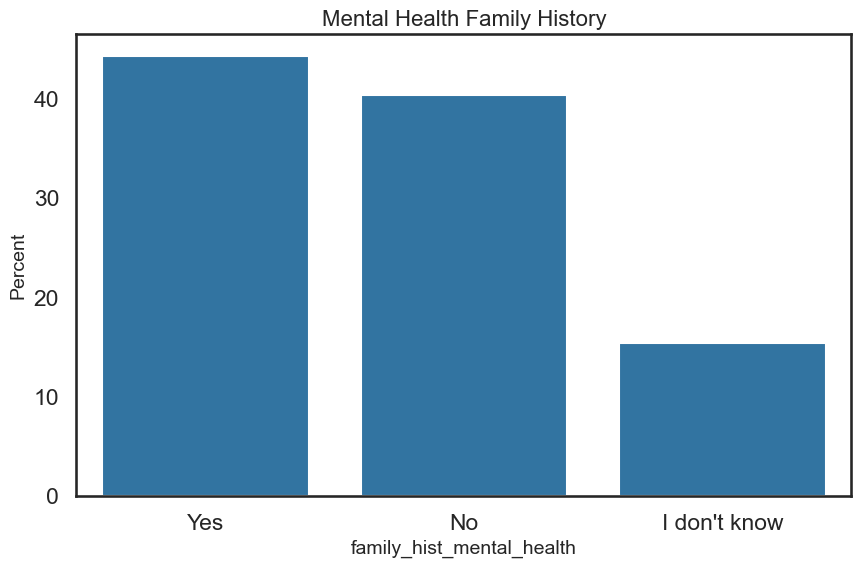

In [ ]:
q = """ 
SELECT AnswerText family_hist_mental_health, COUNT(AnswerText) frequency
FROM Answer
WHERE QuestionID = 6
GROUP BY AnswerText
ORDER BY 2 DESC
"""
fam_hist = pd.read_sql(q, connection)
fam_hist = fam_hist.assign(Percent = lambda x: x.frequency / total_participants * 100)

ax = sns.barplot(fam_hist, x="family_hist_mental_health", y="Percent")
ax.set(title="Mental Health Family History")

In [ ]:
q = """ 
SELECT COUNT(AnswerText) frequency, CASE WHEN AnswerText = 1 THEN 'Yes' 
ELSE 'No' END AS sought_treatment
FROM Answer
WHERE QuestionID = 7
GROUP BY AnswerText
ORDER BY 2 DESC
"""
sought_treatment = pd.read_sql(q, connection)
sought_treatment = sought_treatment.assign(Percent = lambda x: x.frequency / total_participants * 100)

sought_treatment

,frequency,sought_treatment,Percent
0,2412,Yes,57.183499
1,1806,No,42.816501


[Text(0.5, 1.0, 'Past Mental Health Disorder')]

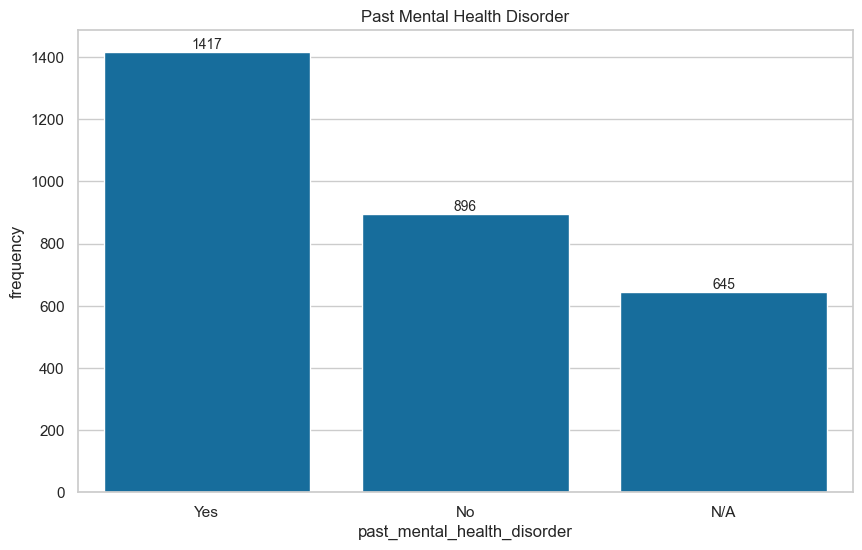

In [ ]:
q = """ 
WITH t1 AS (SELECT CASE WHEN AnswerText LIKE 'Possibly' THEN 'N/A'
WHEN AnswerText = -1 THEN 'N/A' 
WHEN AnswerText LIKE '%know' THEN 'N/A'
WHEN AnswerText LIKE 'Maybe' THEN 'N/A'
ELSE AnswerText END AS past_mental_health_disorder
FROM Answer
WHERE QuestionID = 32)

SELECT past_mental_health_disorder, COUNT(past_mental_health_disorder) frequency
FROM t1
GROUP BY 1
ORDER BY frequency DESC
"""
past_mental_health_disorder = pd.read_sql(q, connection)
ax = sns.barplot(
    past_mental_health_disorder, x="past_mental_health_disorder", y="frequency"
)
ax.bar_label(ax.containers[0], fontsize=10)
ax.set(title="Past Mental Health Disorder")


[Text(0.5, 1.0, 'Current Mental Health Disorder')]

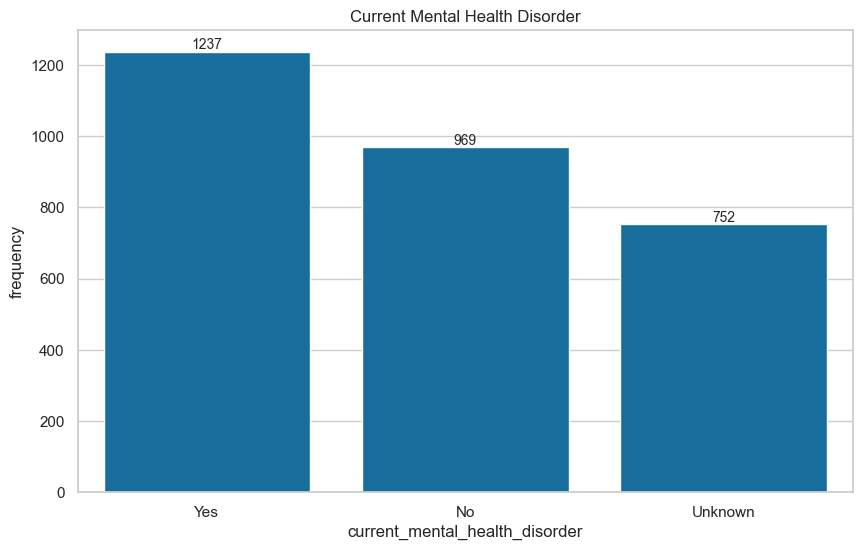

In [ ]:
q = """ 
WITH t1 AS (SELECT CASE WHEN AnswerText LIKE 'Yes' THEN 'Yes' 
WHEN AnswerText LIKE 'No' THEN 'No' 
ELSE 'Unknown' END AS current_mental_health_disorder
FROM Answer
WHERE QuestionID = 33)

SELECT current_mental_health_disorder, COUNT(*) frequency
FROM t1
GROUP BY 1
ORDER BY 2 DESC

"""
current_mental_health_disorder = pd.read_sql(q, connection)
ax = sns.barplot(
    current_mental_health_disorder, x="current_mental_health_disorder", y="frequency"
)
ax.bar_label(ax.containers[0], fontsize=10)
ax.set(title="Current Mental Health Disorder")

In [ ]:
q = """ 
SELECT COUNT(AnswerText) frequency, CASE WHEN AnswerText = -1 THEN 'N/A' 
ELSE AnswerText END AS diagnosis
FROM Answer
WHERE QuestionID = 34
GROUP BY 2
ORDER BY 2 DESC
"""
diagnosis = pd.read_sql(q, connection)
diagnosis = diagnosis.assign(Percent_total_participants = lambda x: x.frequency / total_participants * 100)

diagnosis

,frequency,diagnosis,Percent_total_participants
0,1363,Yes,32.313893
1,732,No,17.354196
2,863,N/A,20.459934


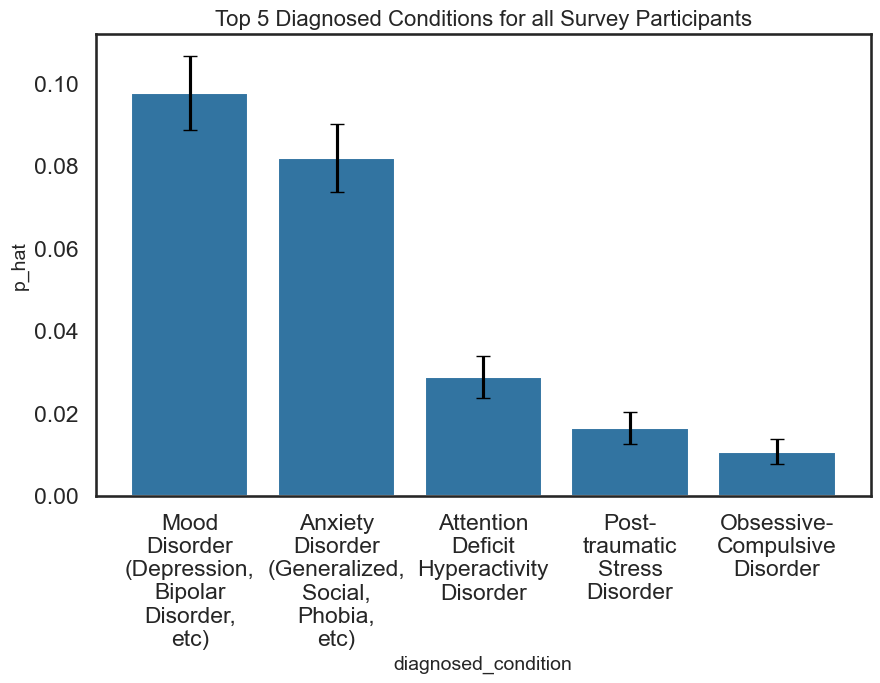

In [ ]:
ax = sns.barplot(x="diagnosed_condition", y="p_hat", data=diagnosed_condition)
wrap_labels(ax, 10)
plt.errorbar(
    diagnosed_condition.diagnosed_condition, diagnosed_condition.p_hat, yerr=diagnosed_condition.ME, fmt="none", c="black", capsize=5
)
plt.title("Top 5 Diagnosed Conditions for all Survey Participants")
plt.show()

In [ ]:
diagnosed_condition["ME"] = diagnosed_condition["frequency"].apply(ME)
diagnosed_condition

,frequency,diagnosed_condition,Percent_total_participants,p_hat,ME
1,412,"Mood Disorder (Depression, Bipolar Disorder, etc)",9.767662,0.097677,0.008959
2,345,"Anxiety Disorder (Generalized, Social, Phobia, etc)",8.179232,0.081792,0.008270
3,121,Attention Deficit Hyperactivity Disorder,2.868658,0.028687,0.005038
4,69,Post-traumatic Stress Disorder,1.635846,0.016358,0.003828
5,45,Obsessive-Compulsive Disorder,1.066856,0.010669,0.003100


In [ ]:
diagnosed_condition = diagnosed_condition.assign(
    p_hat=lambda x: (1.0 * x.frequency) / (1.0 * total_participants)
)
diagnosed_condition

,frequency,diagnosed_condition,Percent_total_participants,p_hat
1,412,"Mood Disorder (Depression, Bipolar Disorder, etc)",9.767662,0.097677
2,345,"Anxiety Disorder (Generalized, Social, Phobia, etc)",8.179232,0.081792
3,121,Attention Deficit Hyperactivity Disorder,2.868658,0.028687
4,69,Post-traumatic Stress Disorder,1.635846,0.016358
5,45,Obsessive-Compulsive Disorder,1.066856,0.010669


In [ ]:
q = """ 
SELECT COUNT(AnswerText) frequency, CASE WHEN AnswerText = -1 THEN 'N/A' ELSE AnswerText END AS diagnosed_condition
FROM Answer
WHERE QuestionID = 115
GROUP BY AnswerText
ORDER BY 1 DESC
LIMIT 6
"""
diagnosed_condition = pd.read_sql(q, connection)
diagnosed_condition = diagnosed_condition.drop(diagnosed_condition[(diagnosed_condition.diagnosed_condition == 'N/A')].index)
diagnosed_condition = diagnosed_condition.assign(Percent_total_participants = lambda x: x.frequency / total_participants * 100)

diagnosed_condition

,frequency,diagnosed_condition,Percent_total_participants
1,412,"Mood Disorder (Depression, Bipolar Disorder, etc)",9.767662
2,345,"Anxiety Disorder (Generalized, Social, Phobia, etc)",8.179232
3,121,Attention Deficit Hyperactivity Disorder,2.868658
4,69,Post-traumatic Stress Disorder,1.635846
5,45,Obsessive-Compulsive Disorder,1.066856


[Text(0.5, 1.0, 'Effective Treatment Work Interference')]

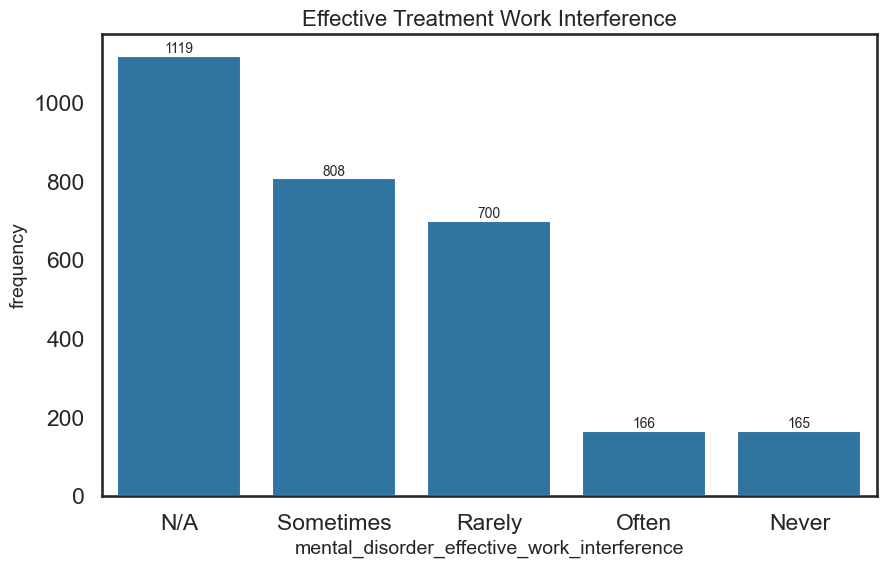

In [ ]:
q = """ 
SELECT COUNT(AnswerText) frequency, CASE WHEN AnswerText LIKE 'Not applicable to me' THEN 'N/A' ELSE AnswerText END AS mental_disorder_effective_work_interference
FROM Answer
WHERE QuestionID = 48
GROUP BY AnswerText
ORDER BY 1 DESC
"""
condition_interfere_work_treatment_effective = pd.read_sql(q, connection)
ax = sns.barplot(
    condition_interfere_work_treatment_effective,
    x="mental_disorder_effective_work_interference",
    y="frequency",
)
ax.bar_label(ax.containers[0], fontsize=10)
ax.set(title="Effective Treatment Work Interference")

[Text(0.5, 1.0, 'Ineffective Treatment Work Interference')]

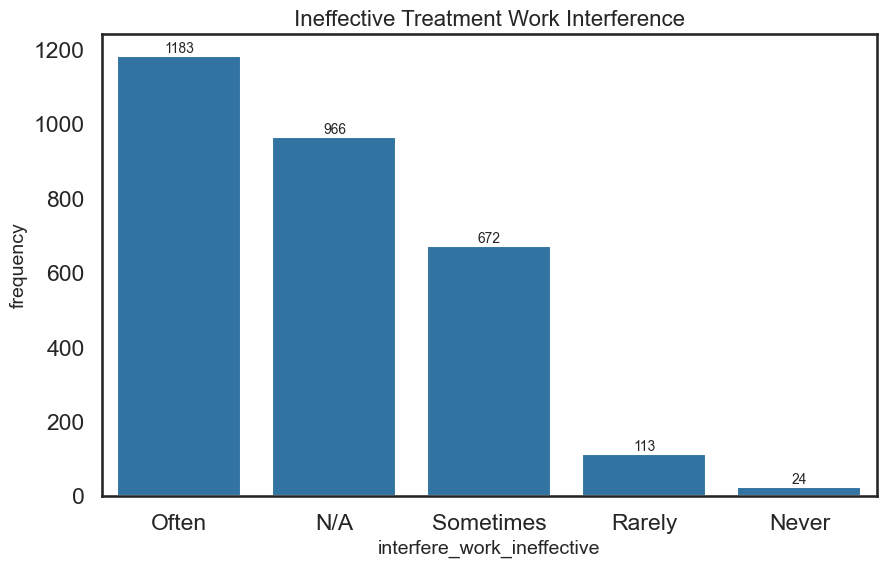

In [ ]:
q = """ 
SELECT COUNT(AnswerText) frequency, CASE WHEN AnswerText LIKE 'Not applicable to me' THEN 'N/A' ELSE AnswerText END AS interfere_work_ineffective
FROM Answer
WHERE QuestionID = 49
GROUP BY AnswerText
ORDER BY 1 DESC
"""
condition_interfere_work_treatment_ineffective = pd.read_sql(q, connection)
ax = sns.barplot(
    condition_interfere_work_treatment_ineffective,
    x="interfere_work_ineffective",
    y="frequency",
)
ax.bar_label(ax.containers[0], fontsize=10)
ax.set(title="Ineffective Treatment Work Interference")

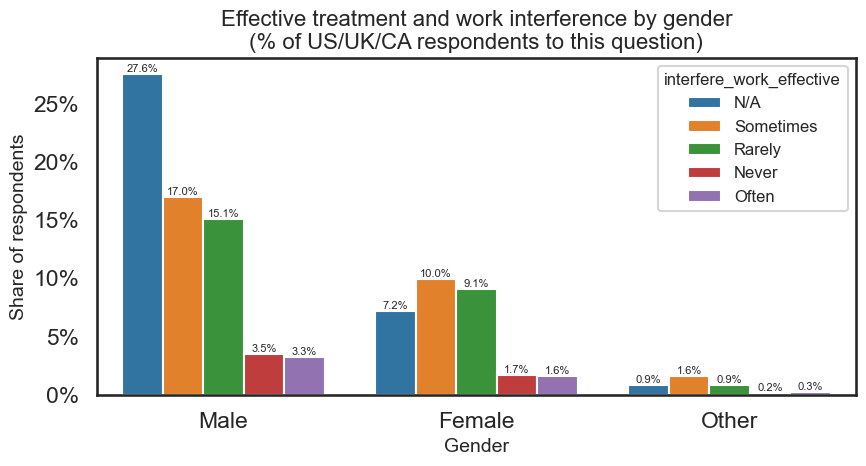

In [ ]:
q = """ 
WITH t1 AS (
    SELECT SurveyID, UserID, AnswerText,
    CASE WHEN AnswerText LIKE 'Female' THEN 'Female'
    WHEN AnswerText LIKE '%Female-identified%' THEN 'Female'
    WHEN AnswerText LIKE '%Woman-identified%' THEN 'Female'
    WHEN AnswerText LIKE 'female' THEN 'Female' 
    WHEN AnswerText LIKE 'MALE' THEN 'Male'
    WHEN AnswerText LIKE '%Male%' THEN 'Male' 
    WHEN AnswerText LIKE 'Masculine' THEN 'Male'  
    WHEN AnswerText LIKE 'Ostensibly Male' THEN 'Male' 
    WHEN AnswerText LIKE 'male' THEN 'Male'  
    Else 'Other' END AS gender
    FROM Answer
    WHERE QuestionID = 2), 

t2 AS (
    SELECT UserID, AnswerText work_country
    FROM Answer
    WHERE QuestionID = 50), 

t3 AS (
    SELECT UserID, CASE WHEN AnswerText LIKE 'Not applicable to me' THEN 'N/A' ELSE AnswerText END AS interfere_work_effective
    FROM Answer
    WHERE QuestionID = 48)

SELECT t1.gender, t3.interfere_work_effective, COUNT(t1.gender) frequency
FROM t1
JOIN t2
ON t1.UserID = t2.UserID
JOIN t3
ON t2.UserID = t3.UserID
WHERE (t2.work_country LIKE 'United States of America' OR t2.work_country LIKE 'United Kingdom' OR t2.work_country LIKE 'Canada')
GROUP BY 1, 2
ORDER BY frequency DESC
"""
from matplotlib.ticker import FuncFormatter

c = pd.read_sql(q, connection).copy()

# Global denominator: all US/UK/CA respondents to Q48
total_q48_top3 = c["frequency"].sum()
c["share_total"] = c["frequency"] / total_q48_top3  # fraction of all respondents

# Match palette length to number of levels
#n_levels = c["interfere_work_effective"].nunique()
#palette = PALETTE[:n_levels]  # or drop palette= and let seaborn choose

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=c,
    x="gender",
    y="share_total",
    hue="interfere_work_effective",
    #palette=palette,
)

ax.set(
    title="Effective treatment and work interference by gender\n(% of US/UK/CA respondents to this question)",
    xlabel="Gender",
    ylabel="Share of respondents",
)
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.0%}"))

# Percent labels on bars (of total)
for container in ax.containers:
    labels = [f"{v*100:.1f}%" for v in container.datavalues]
    ax.bar_label(container, labels=labels, fontsize=8)

plt.tight_layout()


[Text(0.5, 1.0, 'Ineffective Treatment Work Interference with Gender')]

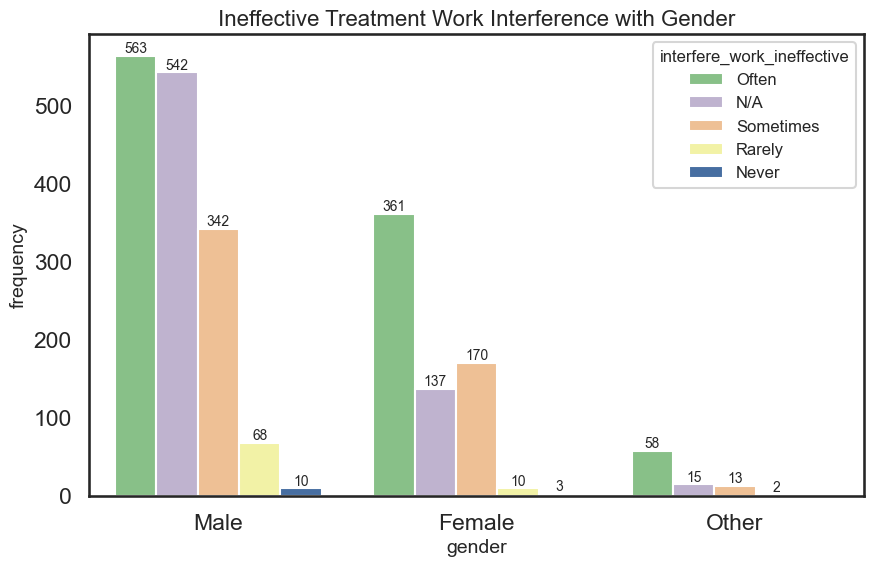

In [ ]:
q = """ 
WITH t1 AS (
    SELECT SurveyID, UserID, AnswerText,
    CASE WHEN AnswerText LIKE 'Female' THEN 'Female'
    WHEN AnswerText LIKE '%Female-identified%' THEN 'Female'
    WHEN AnswerText LIKE '%Woman-identified%' THEN 'Female'
    WHEN AnswerText LIKE 'female' THEN 'Female' 
    WHEN AnswerText LIKE 'MALE' THEN 'Male'
    WHEN AnswerText LIKE '%Male%' THEN 'Male' 
    WHEN AnswerText LIKE 'Masculine' THEN 'Male'  
    WHEN AnswerText LIKE 'Ostensibly Male' THEN 'Male' 
    WHEN AnswerText LIKE 'male' THEN 'Male'  
    Else 'Other' END AS gender
    FROM Answer
    WHERE QuestionID = 2), 

t2 AS (
    SELECT UserID, AnswerText work_country
    FROM Answer
    WHERE QuestionID = 50), 

t3 AS (
    SELECT UserID, CASE WHEN AnswerText LIKE 'Not applicable to me' THEN 'N/A' ELSE AnswerText END AS interfere_work_ineffective
    FROM Answer
    WHERE QuestionID = 49)

SELECT t1.gender, t3.interfere_work_ineffective, COUNT(t1.gender) frequency
FROM t1
JOIN t2
ON t1.UserID = t2.UserID
JOIN t3
ON t2.UserID = t3.UserID
WHERE (t2.work_country LIKE 'United States of America' OR t2.work_country LIKE 'United Kingdom' OR t2.work_country LIKE 'Canada')
GROUP BY 1, 2
ORDER BY frequency DESC
"""
c = pd.read_sql(q, connection)

sns.color_palette('Accent')
ax = sns.barplot(c, x="gender", y="frequency", hue="interfere_work_ineffective", palette='Accent')
ax.bar_label(ax.containers[0], fontsize=10)
ax.bar_label(ax.containers[1], fontsize=10)
ax.bar_label(ax.containers[2], fontsize=10)
ax.bar_label(ax.containers[3], fontsize=10)
ax.bar_label(ax.containers[4], fontsize=10)

ax.set(title="Ineffective Treatment Work Interference with Gender")

In [ ]:
q = """ 
WITH t1 AS (SELECT CASE WHEN AnswerText = -1 THEN 'N/A' 
WHEN AnswerText LIKE 'Not applicable to me' THEN 'N/A' 
ELSE AnswerText END AS condition_productivity_suffers
FROM Answer
WHERE QuestionID = 54) 
SELECT condition_productivity_suffers, COUNT(condition_productivity_suffers) frequency
FROM t1
GROUP BY 1
ORDER BY 2
"""
condition_productivity_suffers = pd.read_sql(q, connection)
condition_productivity_suffers = condition_productivity_suffers.assign(Percent_total_participants = lambda x: x.frequency / total_participants * 100)

condition_productivity_suffers

,condition_productivity_suffers,frequency,Percent_total_participants
0,No,26,0.616406
1,Unsure,60,1.422475
2,Yes,367,8.700806
3,N/A,2505,59.388336


Quite a few people did not answer this question or found it not applicable to them, as the percentages here do not add up to 100. The only interesting thing to note here is that almost 9% of participants say that their productivity is affected by a mental health condition.

Grouped by gender for participants in the USA, UK, and Canada:

[Text(0.5, 1.0, 'Productivity Affected with Gender')]

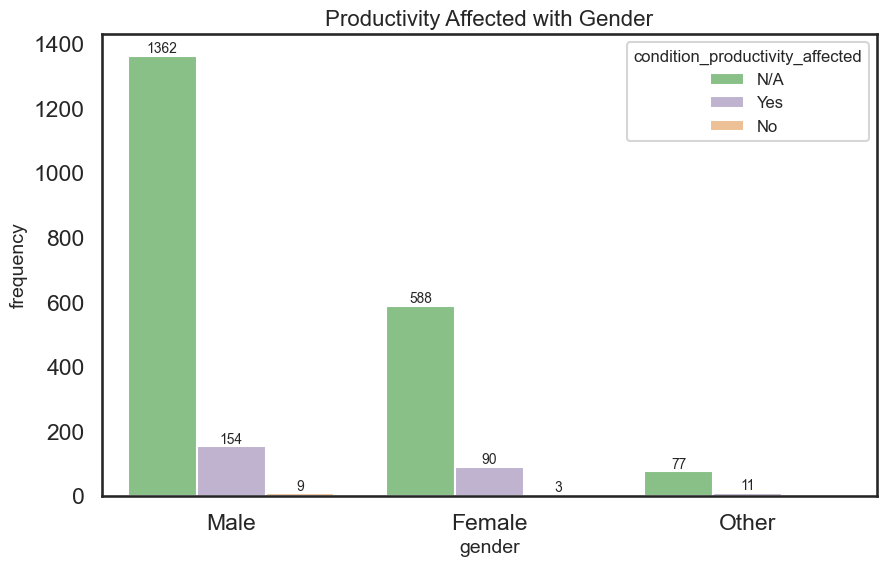

In [ ]:
q = """ 
WITH t1 AS (
    SELECT SurveyID, UserID, AnswerText,
    CASE WHEN AnswerText LIKE 'Female' THEN 'Female'
    WHEN AnswerText LIKE '%Female-identified%' THEN 'Female'
    WHEN AnswerText LIKE '%Woman-identified%' THEN 'Female'
    WHEN AnswerText LIKE 'female' THEN 'Female' 
    WHEN AnswerText LIKE 'MALE' THEN 'Male'
    WHEN AnswerText LIKE '%Male%' THEN 'Male' 
    WHEN AnswerText LIKE 'Masculine' THEN 'Male'  
    WHEN AnswerText LIKE 'Ostensibly Male' THEN 'Male' 
    WHEN AnswerText LIKE 'male' THEN 'Male'  
    Else 'Other' END AS gender
    FROM Answer
    WHERE QuestionID = 2), 

t2 AS (
    SELECT UserID, AnswerText work_country
    FROM Answer
    WHERE QuestionID = 50), 

t3 AS (
    SELECT UserID, CASE WHEN AnswerText = -1 THEN 'N/A' 
    WHEN AnswerText LIKE 'Not applicable to me' THEN 'N/A' 
    WHEN AnswerText LIKE 'Unsure' THEN 'N/A'
    ELSE AnswerText END AS condition_productivity_affected
    FROM Answer
    WHERE QuestionID = 54)

SELECT t1.gender, t3.condition_productivity_affected, COUNT(t1.gender) frequency
FROM t1
JOIN t2
ON t1.UserID = t2.UserID
JOIN t3
ON t2.UserID = t3.UserID
WHERE (t2.work_country LIKE 'United States of America' OR t2.work_country LIKE 'United Kingdom' OR t2.work_country LIKE 'Canada')
GROUP BY 1, 2
ORDER BY frequency DESC
"""
c = pd.read_sql(q, connection)

sns.color_palette('Accent')
ax = sns.barplot(c, x="gender", y="frequency", hue="condition_productivity_affected", palette='Accent')
ax.bar_label(ax.containers[0], fontsize=10)
ax.bar_label(ax.containers[1], fontsize=10)
ax.bar_label(ax.containers[2], fontsize=10)


ax.set(title="Productivity Affected with Gender")

## Grouping Variables and Conclusions:

TODO: just keep one of these? 

Looking at participant's answer to having a current mental health disorder who answered 'yes' to having a past mental health disorder as well as 'yes' to having a family history of mental health disorders, in the USA, UK, or Canada: 

Note: grouped by year

[Text(0.5, 1.0, 'Current Disorder with Family History and Past Disorder')]

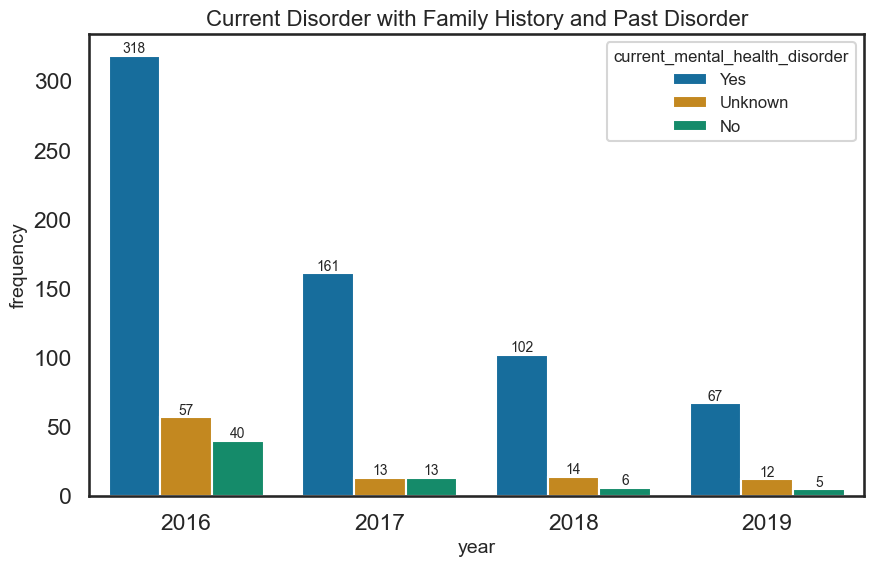

In [ ]:
q = """ 
WITH t1 AS (
    SELECT SurveyID, UserID, AnswerText,
    CASE WHEN AnswerText LIKE 'Female' THEN 'Female'
    WHEN AnswerText LIKE '%Female-identified%' THEN 'Female'
    WHEN AnswerText LIKE '%Woman-identified%' THEN 'Female'
    WHEN AnswerText LIKE 'female' THEN 'Female' 
    WHEN AnswerText LIKE 'MALE' THEN 'Male'
    WHEN AnswerText LIKE '%Male%' THEN 'Male' 
    WHEN AnswerText LIKE 'Masculine' THEN 'Male'  
    WHEN AnswerText LIKE 'Ostensibly Male' THEN 'Male' 
    WHEN AnswerText LIKE 'male' THEN 'Male'  
    Else 'Other' END AS gender
    FROM Answer
    WHERE QuestionID = 2), 

t2 AS (
    SELECT UserID, AnswerText work_country
    FROM Answer
    WHERE QuestionID = 50), 

t3 AS (
    SELECT UserID, AnswerText family_hist
    FROM Answer
    WHERE QuestionID = 6), 

t4 AS (
    SELECT UserID, CASE WHEN AnswerText LIKE 'Possibly' THEN 'Maybe'
    WHEN AnswerText = -1 THEN 'NA' 
    ELSE AnswerText END AS past_mental_health_disorder
    FROM Answer
    WHERE QuestionID = 32), 

t5 AS (
    SELECT UserID, CASE WHEN AnswerText = -1 THEN 'N/A' 
    ELSE AnswerText END AS diagnosis
    FROM Answer
    WHERE QuestionID = 34),

t6 AS (
    SELECT UserID, CASE WHEN AnswerText LIKE 'Yes' THEN 'Yes' 
    WHEN AnswerText LIKE 'No' THEN 'No' 
    ELSE 'Unknown' END AS current_mental_health_disorder
    FROM Answer
    WHERE QuestionID = 33)


SELECT t1.SurveyID year, t6.current_mental_health_disorder, COUNT(t1.SurveyID) frequency
FROM t1
JOIN t2
ON t1.UserID = t2.UserID
JOIN t3
ON t2.UserID = t3.UserID
JOIN t4
ON t3.UserID = t4.UserID
JOIN t5 
ON t4.UserID = t5.UserID
JOIN t6
ON t5.UserID = t6.UserID
WHERE t4.past_mental_health_disorder LIKE 'yes' AND t3.family_hist LIKE 'yes' AND (t2.work_country LIKE 'United States of America' OR t2.work_country LIKE 'United Kingdom' OR t2.work_country LIKE 'Canada')
GROUP BY 1, 2
ORDER BY frequency DESC
"""
c = pd.read_sql(q, connection)

sns.color_palette('colorblind')
ax = sns.barplot(c, x="year", y="frequency", hue="current_mental_health_disorder", palette='colorblind')
ax.bar_label(ax.containers[0], fontsize=10)
ax.bar_label(ax.containers[1], fontsize=10)
ax.bar_label(ax.containers[2], fontsize=10)

ax.set(title="Current Disorder with Family History and Past Disorder")

After answering 'yes' to a family history of mental health issues and 'yes' to having a past mental health disorder, participants in the USA, UK, and Canada also answer mostly 'yes' to having a current mental health disorder. 

Now, looking at the opposite effect: 
Looking at participant's answers to having a current mental health disorder who answered 'no' to having a past mental health disorder as well as 'no' to having a family history of mental health disorders, in the USA, UK, or Canada: 

Note: also grouped by year

[Text(0.5, 1.0, 'Current Disorder with No Family History and No Past Disorder')]

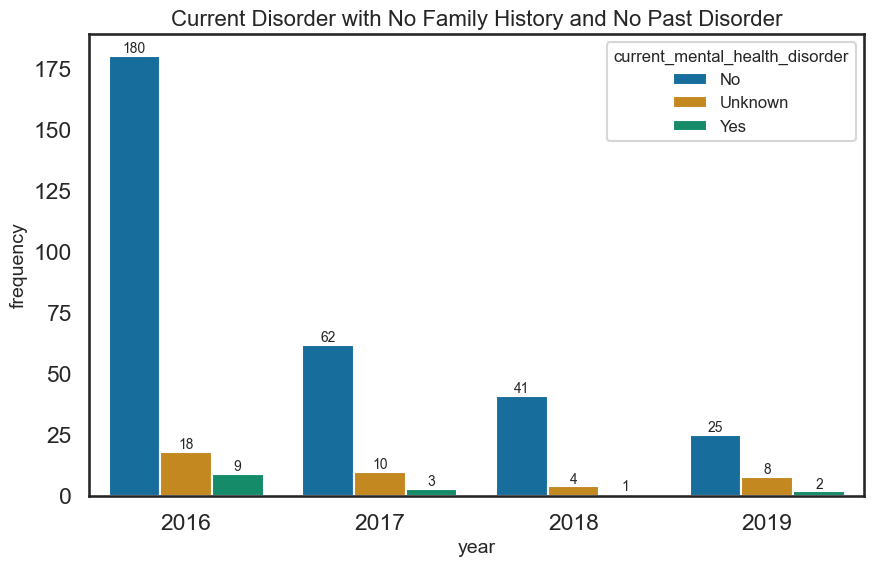

In [ ]:
q = """ 
WITH t1 AS (
    SELECT SurveyID, UserID, AnswerText,
    CASE WHEN AnswerText LIKE 'Female' THEN 'Female'
    WHEN AnswerText LIKE '%Female-identified%' THEN 'Female'
    WHEN AnswerText LIKE '%Woman-identified%' THEN 'Female'
    WHEN AnswerText LIKE 'female' THEN 'Female' 
    WHEN AnswerText LIKE 'MALE' THEN 'Male'
    WHEN AnswerText LIKE '%Male%' THEN 'Male' 
    WHEN AnswerText LIKE 'Masculine' THEN 'Male'  
    WHEN AnswerText LIKE 'Ostensibly Male' THEN 'Male' 
    WHEN AnswerText LIKE 'male' THEN 'Male'  
    Else 'Other' END AS gender
    FROM Answer
    WHERE QuestionID = 2), 

t2 AS (
    SELECT UserID, AnswerText work_country
    FROM Answer
    WHERE QuestionID = 50), 

t3 AS (
    SELECT UserID, AnswerText family_hist
    FROM Answer
    WHERE QuestionID = 6), 

t4 AS (
    SELECT UserID, CASE WHEN AnswerText LIKE 'Possibly' THEN 'Maybe'
    WHEN AnswerText = -1 THEN 'NA' 
    ELSE AnswerText END AS past_mental_health_disorder
    FROM Answer
    WHERE QuestionID = 32), 

t5 AS (
    SELECT UserID, CASE WHEN AnswerText = -1 THEN 'N/A' 
    ELSE AnswerText END AS diagnosis
    FROM Answer
    WHERE QuestionID = 34),

t6 AS (
    SELECT UserID, CASE WHEN AnswerText LIKE 'Yes' THEN 'Yes' 
    WHEN AnswerText LIKE 'No' THEN 'No' 
    ELSE 'Unknown' END AS current_mental_health_disorder
    FROM Answer
    WHERE QuestionID = 33)


SELECT t1.SurveyID year, t6.current_mental_health_disorder, COUNT(t1.SurveyID) frequency
FROM t1
JOIN t2
ON t1.UserID = t2.UserID
JOIN t3
ON t2.UserID = t3.UserID
JOIN t4
ON t3.UserID = t4.UserID
JOIN t5 
ON t4.UserID = t5.UserID
JOIN t6
ON t5.UserID = t6.UserID
WHERE t4.past_mental_health_disorder LIKE 'No' AND t3.family_hist LIKE 'No' AND (t2.work_country LIKE 'United States of America' OR t2.work_country LIKE 'United Kingdom' OR t2.work_country LIKE 'Canada')
GROUP BY 1, 2
ORDER BY frequency DESC
"""
c = pd.read_sql(q, connection)

sns.color_palette('colorblind')
ax = sns.barplot(c, x="year", y="frequency", hue="current_mental_health_disorder", palette='colorblind')
ax.bar_label(ax.containers[0], fontsize=10)
ax.bar_label(ax.containers[1], fontsize=10)
ax.bar_label(ax.containers[2], fontsize=10)

ax.set(title="Current Disorder with No Family History and No Past Disorder")

On the contrary, when survey respondants answer 'no' to having a family history of mental health issues and 'no' to previous mental health issues, they most frequently do not seem to have a current mental health disorder.

Next, given a negative response to the previous questions: 
- 'No' to current mental health disorder, 
- 'No' to past mental health disorder
- 'No' to having a family history of mental health disorders, 

do participants working in the USA, UK, or Canada find their work productivity affected through 2016-2019? 

[Text(0.5, 1.0, 'Productivity affected After Negative Response to Previous Questions')]

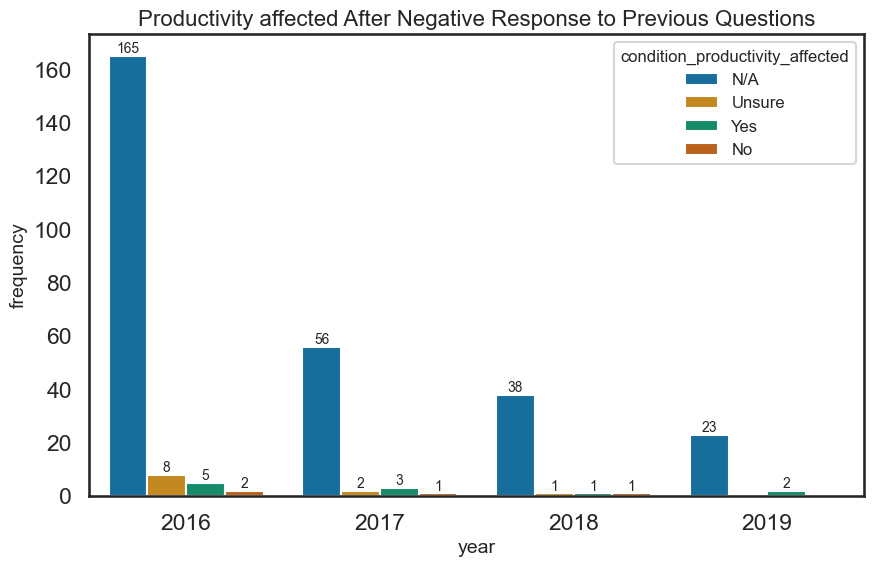

In [ ]:
q = """ 
WITH t1 AS (
    SELECT SurveyID, UserID, AnswerText,
    CASE WHEN AnswerText LIKE 'Female' THEN 'Female'
    WHEN AnswerText LIKE '%Female-identified%' THEN 'Female'
    WHEN AnswerText LIKE '%Woman-identified%' THEN 'Female'
    WHEN AnswerText LIKE 'female' THEN 'Female' 
    WHEN AnswerText LIKE 'MALE' THEN 'Male'
    WHEN AnswerText LIKE '%Male%' THEN 'Male' 
    WHEN AnswerText LIKE 'Masculine' THEN 'Male'  
    WHEN AnswerText LIKE 'Ostensibly Male' THEN 'Male' 
    WHEN AnswerText LIKE 'male' THEN 'Male'  
    Else 'Other' END AS gender
    FROM Answer
    WHERE QuestionID = 2), 

t2 AS (
    SELECT UserID, AnswerText work_country
    FROM Answer
    WHERE QuestionID = 50), 

t3 AS (
    SELECT UserID, AnswerText family_hist
    FROM Answer
    WHERE QuestionID = 6), 

t4 AS (
    SELECT UserID, CASE WHEN AnswerText LIKE 'Possibly' THEN 'Maybe'
    WHEN AnswerText = -1 THEN 'NA' 
    ELSE AnswerText END AS past_mental_health_disorder
    FROM Answer
    WHERE QuestionID = 32), 

t5 AS (
    SELECT UserID, CASE WHEN AnswerText = -1 THEN 'N/A' 
    ELSE AnswerText END AS diagnosis
    FROM Answer
    WHERE QuestionID = 34),

t6 AS (
    SELECT UserID, CASE WHEN AnswerText LIKE 'Yes' THEN 'Yes' 
    WHEN AnswerText LIKE 'No' THEN 'No' 
    ELSE 'Unknown' END AS current_mental_health_disorder
    FROM Answer
    WHERE QuestionID = 33), 

t7 AS (
    SELECT UserID, CASE WHEN AnswerText = -1 THEN 'N/A' 
    WHEN AnswerText LIKE 'Not applicable to me' THEN 'N/A' 
    ELSE AnswerText END AS condition_productivity_affected
    FROM Answer
    WHERE QuestionID = 54)


SELECT t1.SurveyID year, t7.condition_productivity_affected, COUNT(t1.SurveyID) frequency
FROM t1
JOIN t2
ON t1.UserID = t2.UserID
JOIN t3
ON t2.UserID = t3.UserID
JOIN t4
ON t3.UserID = t4.UserID
JOIN t5 
ON t4.UserID = t5.UserID
JOIN t6
ON t5.UserID = t6.UserID
JOIN t7
ON t6.UserID = t7.UserID
WHERE t6.current_mental_health_disorder LIKE 'no' AND t4.past_mental_health_disorder LIKE 'No' AND t3.family_hist LIKE 'No' AND (t2.work_country LIKE 'United States of America' OR t2.work_country LIKE 'United Kingdom' OR t2.work_country LIKE 'Canada')
GROUP BY 1, 2
ORDER BY frequency DESC
"""
c = pd.read_sql(q, connection)

sns.color_palette('colorblind')

ax = sns.barplot(c, x="year", y="frequency", hue="condition_productivity_affected", palette='colorblind')
ax.bar_label(ax.containers[0], fontsize=10)
ax.bar_label(ax.containers[1], fontsize=10)
ax.bar_label(ax.containers[2], fontsize=10)
ax.bar_label(ax.containers[3], fontsize=10)


ax.set(title="Productivity affected After Negative Response to Previous Questions")

When answering 'no' to having a family or personal history of mental illness as well as 'no' to having a current mental health condition, it makes sense that this question is not applicable to the majority of survey respondents.

Next, looking at the opposite trend: given a positive response to the previous questions: 
- 'Yes' to current mental health disorder, 
- 'Yes' to past mental health disorder
- 'Yes' to having a family history of mental health disorders, 

do participants working in the USA, UK, or Canada find their work productivity affected from 2016-2019? 

[Text(0.5, 1.0, 'Productivity affected with Positive Answer to Previous Questions')]

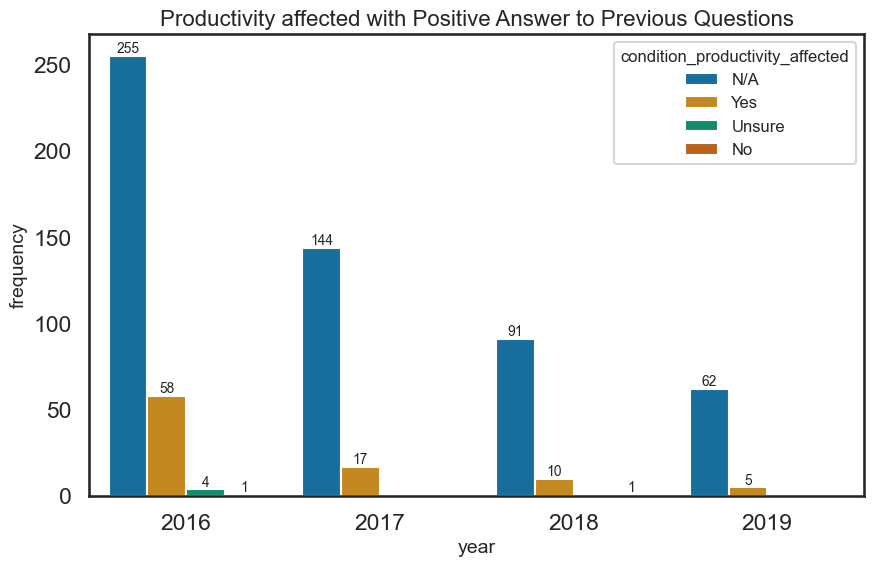

In [ ]:
q = """ 
WITH t1 AS (
    SELECT SurveyID, UserID, AnswerText,
    CASE WHEN AnswerText LIKE 'Female' THEN 'Female'
    WHEN AnswerText LIKE '%Female-identified%' THEN 'Female'
    WHEN AnswerText LIKE '%Woman-identified%' THEN 'Female'
    WHEN AnswerText LIKE 'female' THEN 'Female' 
    WHEN AnswerText LIKE 'MALE' THEN 'Male'
    WHEN AnswerText LIKE '%Male%' THEN 'Male' 
    WHEN AnswerText LIKE 'Masculine' THEN 'Male'  
    WHEN AnswerText LIKE 'Ostensibly Male' THEN 'Male' 
    WHEN AnswerText LIKE 'male' THEN 'Male'  
    Else 'Other' END AS gender
    FROM Answer
    WHERE QuestionID = 2), 

t2 AS (
    SELECT UserID, AnswerText work_country
    FROM Answer
    WHERE QuestionID = 50), 

t3 AS (
    SELECT UserID, AnswerText family_hist
    FROM Answer
    WHERE QuestionID = 6), 

t4 AS (
    SELECT UserID, CASE WHEN AnswerText LIKE 'Possibly' THEN 'Maybe'
    WHEN AnswerText = -1 THEN 'NA' 
    ELSE AnswerText END AS past_mental_health_disorder
    FROM Answer
    WHERE QuestionID = 32), 

t5 AS (
    SELECT UserID, CASE WHEN AnswerText = -1 THEN 'N/A' 
    ELSE AnswerText END AS diagnosis
    FROM Answer
    WHERE QuestionID = 34),

t6 AS (
    SELECT UserID, CASE WHEN AnswerText LIKE 'Yes' THEN 'Yes' 
    WHEN AnswerText LIKE 'No' THEN 'No' 
    ELSE 'Unknown' END AS current_mental_health_disorder
    FROM Answer
    WHERE QuestionID = 33), 

t7 AS (
    SELECT UserID, CASE WHEN AnswerText = -1 THEN 'N/A' 
    WHEN AnswerText LIKE 'Not applicable to me' THEN 'N/A' 
    ELSE AnswerText END AS condition_productivity_affected
    FROM Answer
    WHERE QuestionID = 54)


SELECT t1.SurveyID year, t7.condition_productivity_affected, COUNT(t1.SurveyID) frequency
FROM t1
JOIN t2
ON t1.UserID = t2.UserID
JOIN t3
ON t2.UserID = t3.UserID
JOIN t4
ON t3.UserID = t4.UserID
JOIN t5 
ON t4.UserID = t5.UserID
JOIN t6
ON t5.UserID = t6.UserID
JOIN t7
ON t6.UserID = t7.UserID
WHERE t6.current_mental_health_disorder LIKE 'yes' AND t4.past_mental_health_disorder LIKE 'yes' AND t3.family_hist LIKE 'yes' AND (t2.work_country LIKE 'United States of America' OR t2.work_country LIKE 'United Kingdom' OR t2.work_country LIKE 'Canada')
GROUP BY 1, 2
ORDER BY frequency DESC
"""
c = pd.read_sql(q, connection)

sns.color_palette('colorblind')
ax = sns.barplot(c, x="year", y="frequency", hue="condition_productivity_affected", palette='colorblind')
ax.bar_label(ax.containers[0], fontsize=10)
ax.bar_label(ax.containers[1], fontsize=10)
ax.bar_label(ax.containers[2], fontsize=10)
ax.bar_label(ax.containers[3], fontsize=10)


ax.set(title="Productivity affected with Positive Answer to Previous Questions")

As compared to the result from the previous question, with positive answers to mental health issues in the past, present, and family history, work productivity is more affected by mental health issues in the USA, UK, and Canada. 

Finally, looking at the percentage of work time affected: given a positive response to the previous questions: 
- 'Yes' to current mental health disorder, 
- 'Yes' to past mental health disorder
- 'Yes' to having a family history of mental health disorders, 
- 'Yes' to having their work productivity affected by a mental health disorder, 

do participants working in the USA, UK, or Canada find their work productivity affected from 2016-2019? 

[Text(0.5, 1.0, 'Percent Work Affected with Previous Positive Answers')]

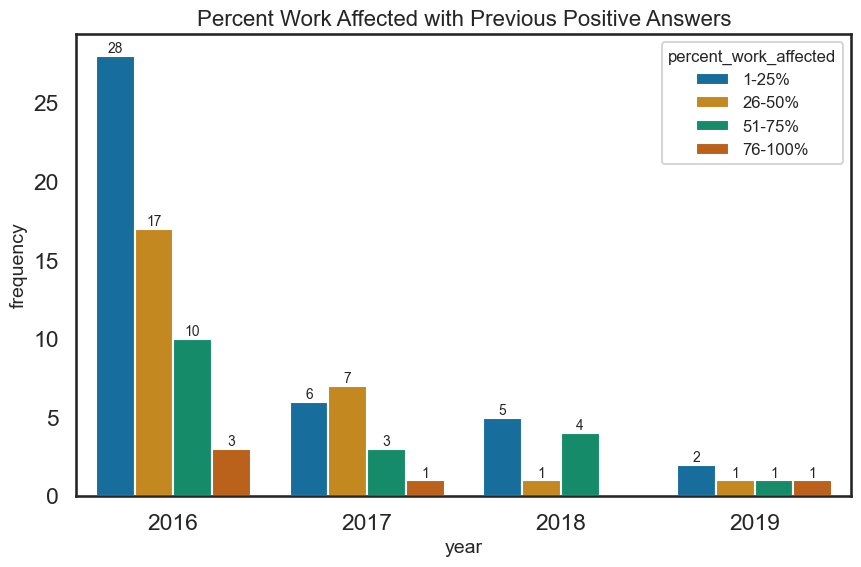

In [ ]:
q = """ 
WITH t1 AS (
    SELECT SurveyID, UserID, AnswerText,
    CASE WHEN AnswerText LIKE 'Female' THEN 'Female'
    WHEN AnswerText LIKE '%Female-identified%' THEN 'Female'
    WHEN AnswerText LIKE '%Woman-identified%' THEN 'Female'
    WHEN AnswerText LIKE 'female' THEN 'Female' 
    WHEN AnswerText LIKE 'MALE' THEN 'Male'
    WHEN AnswerText LIKE '%Male%' THEN 'Male' 
    WHEN AnswerText LIKE 'Masculine' THEN 'Male'  
    WHEN AnswerText LIKE 'Ostensibly Male' THEN 'Male' 
    WHEN AnswerText LIKE 'male' THEN 'Male'  
    Else 'Other' END AS gender
    FROM Answer
    WHERE QuestionID = 2), 

t2 AS (
    SELECT UserID, AnswerText work_country
    FROM Answer
    WHERE QuestionID = 50), 

t3 AS (
    SELECT UserID, AnswerText family_hist
    FROM Answer
    WHERE QuestionID = 6), 

t4 AS (
    SELECT UserID, CASE WHEN AnswerText LIKE 'Possibly' THEN 'Maybe'
    WHEN AnswerText = -1 THEN 'NA' 
    ELSE AnswerText END AS past_mental_health_disorder
    FROM Answer
    WHERE QuestionID = 32), 

t5 AS (
    SELECT UserID, CASE WHEN AnswerText = -1 THEN 'N/A' 
    ELSE AnswerText END AS diagnosis
    FROM Answer
    WHERE QuestionID = 34),

t6 AS (
    SELECT UserID, CASE WHEN AnswerText LIKE 'Yes' THEN 'Yes' 
    WHEN AnswerText LIKE 'No' THEN 'No' 
    ELSE 'Unknown' END AS current_mental_health_disorder
    FROM Answer
    WHERE QuestionID = 33), 

t7 AS (
    SELECT UserID, CASE WHEN AnswerText = -1 THEN 'N/A' 
    WHEN AnswerText LIKE 'Not applicable to me' THEN 'N/A' 
    ELSE AnswerText END AS condition_productivity_affected
    FROM Answer
    WHERE QuestionID = 54), 

t8 AS (
    SELECT UserID, CASE WHEN AnswerText = -1 THEN 'N/A' ELSE AnswerText END AS percent_work_affected
    FROM Answer
    WHERE QuestionID = 55)


SELECT t1.SurveyID year, t8.percent_work_affected, COUNT(t1.SurveyID) frequency
FROM t1
JOIN t2
ON t1.UserID = t2.UserID
JOIN t3
ON t2.UserID = t3.UserID
JOIN t4
ON t3.UserID = t4.UserID
JOIN t5 
ON t4.UserID = t5.UserID
JOIN t6
ON t5.UserID = t6.UserID
JOIN t7
ON t6.UserID = t7.UserID
JOIN t8 
ON t7.UserID = t8.UserID 
WHERE t7.condition_productivity_affected LIKE 'yes' AND t6.current_mental_health_disorder LIKE 'yes' AND t4.past_mental_health_disorder LIKE 'yes' AND t3.family_hist LIKE 'yes' AND (t2.work_country LIKE 'United States of America' OR t2.work_country LIKE 'United Kingdom' OR t2.work_country LIKE 'Canada')
GROUP BY 1, 2
ORDER BY frequency DESC
"""
c = pd.read_sql(q, connection)

sns.color_palette('colorblind')
ax = sns.barplot(c, x="year", y="frequency", hue="percent_work_affected", palette='colorblind')
ax.bar_label(ax.containers[0], fontsize=10)
ax.bar_label(ax.containers[1], fontsize=10)
ax.bar_label(ax.containers[2], fontsize=10)
ax.bar_label(ax.containers[3], fontsize=10)


ax.set(title="Percent Work Affected with Previous Positive Answers")

In the USA, UK, and Canada, when participants have answered 'yes' to previous questions examined as well as 'yes' to having their work affected by their mental health condition, the largest estimated work percentage affected is 1-25% in 2016. 

In [ ]:
q = """ 
SELECT COUNT(AnswerText) frequency, CASE WHEN AnswerText = -1 THEN 'N/A' ELSE AnswerText END AS percent_work_affected
FROM Answer
WHERE QuestionID = 55
GROUP BY AnswerText
ORDER BY 2 DESC
"""
percent_work_affected = pd.read_sql(q, connection)
percent_work_affected = percent_work_affected.assign(Percent_total_participants = lambda x: x.frequency / total_participants * 100)

percent_work_affected

,frequency,percent_work_affected,Percent_total_participants
0,2591,N/A,61.427217
1,25,76-100%,0.592698
2,53,51-75%,1.256520
3,125,26-50%,2.963490
4,164,1-25%,3.888099


[Text(0.5, 1.0, 'Percent Work Time Affected Given Mental Health Condition')]

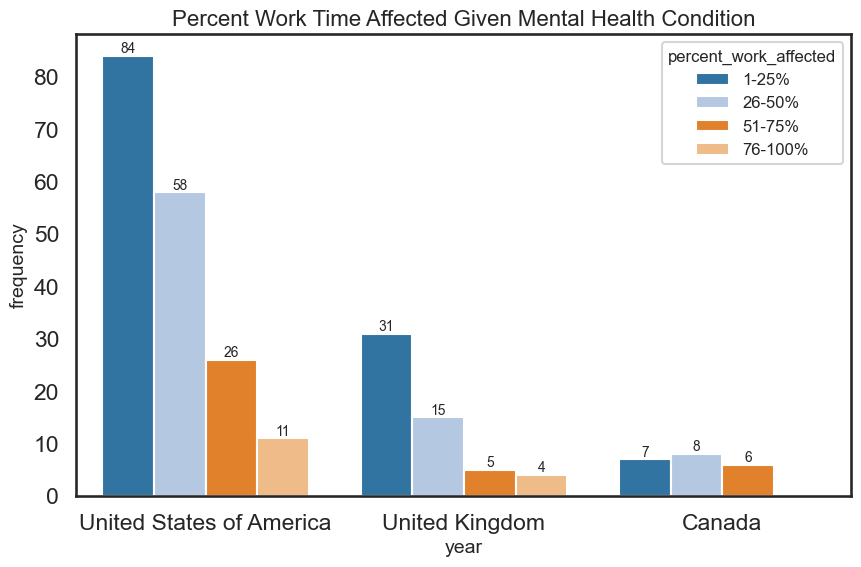

In [ ]:
q = """ 
WITH t1 AS (
    SELECT SurveyID, UserID, AnswerText,
    CASE WHEN AnswerText LIKE 'Female' THEN 'Female'
    WHEN AnswerText LIKE '%Female-identified%' THEN 'Female'
    WHEN AnswerText LIKE '%Woman-identified%' THEN 'Female'
    WHEN AnswerText LIKE 'female' THEN 'Female' 
    WHEN AnswerText LIKE 'MALE' THEN 'Male'
    WHEN AnswerText LIKE '%Male%' THEN 'Male' 
    WHEN AnswerText LIKE 'Masculine' THEN 'Male'  
    WHEN AnswerText LIKE 'Ostensibly Male' THEN 'Male' 
    WHEN AnswerText LIKE 'male' THEN 'Male'  
    Else 'Other' END AS gender
    FROM Answer
    WHERE QuestionID = 2), 

t2 AS (
    SELECT UserID, AnswerText work_country
    FROM Answer
    WHERE QuestionID = 50), 

t3 AS (
    SELECT UserID, CASE WHEN AnswerText = -1 THEN 'N/A' ELSE AnswerText END AS percent_work_affected
    FROM Answer
    WHERE QuestionID = 55)

SELECT t2.work_country year, t3.percent_work_affected, COUNT(t2.work_country) frequency
FROM t1
JOIN t2
ON t1.UserID = t2.UserID
JOIN t3
ON t2.UserID = t3.UserID
WHERE (t2.work_country LIKE 'United States of America' OR t2.work_country LIKE 'United Kingdom' OR t2.work_country LIKE 'Canada')
GROUP BY 1, 2
ORDER BY frequency DESC
"""
c = pd.read_sql(q, connection)
c = c.drop(c[(c.percent_work_affected == 'N/A')].index)

sns.color_palette('tab20')
ax = sns.barplot(c, x="year", y="frequency", hue="percent_work_affected", palette='tab20')
ax.bar_label(ax.containers[0], fontsize=10)
ax.bar_label(ax.containers[1], fontsize=10)
ax.bar_label(ax.containers[2], fontsize=10)
ax.bar_label(ax.containers[3], fontsize=10)


ax.set(title="Percent Work Time Affected Given Mental Health Condition")



In [ ]:
def ME(x):
    n = total_participants_USA_UK_Canada
    z = 1.96
    phat = (x * 1.0) / (n * 1.0)
    if (n * phat) > 5 and (n * (1 - phat)) > 5:
        SE = m.sqrt((phat * (1 - phat)) / n)
        margin_error = z * SE
        return margin_error
    else:
        return "Not large enough sample size"

In [ ]:
@dataclass
class DBConfig:
    """Configuration for connecting to the mental health SQLite database."""

    path: str = "mental_health.sqlite"


def get_connection(config: Optional[DBConfig] = None) -> sqlite3.Connection:
    """
    Return a SQLite connection to the mental health database.

    Parameters
    ----------
    config : DBConfig, optional
        Database configuration. If None, uses default path.

    Returns
    -------
    sqlite3.Connection
        Open SQLite connection. Caller is responsible for closing it.
    """
    cfg = config or DBConfig()
    return sqlite3.connect(cfg.path)


def run_query(query: str, params: Optional[Iterable[object]] = None) -> pd.DataFrame:
    """
    Execute a SQL query against the mental health database.

    Parameters
    ----------
    query : str
        SQL query string, may contain placeholders (e.g. ?).
    params : iterable of object, optional
        Parameters corresponding to placeholders in the query.

    Returns
    -------
    pandas.DataFrame
        Result of the query as a DataFrame.
    """
    with get_connection() as conn:
        return pd.read_sql_query(query, conn, params=params or [])


def get_table(table: str) -> pd.DataFrame:
    """
    Load an entire table from the mental health database.

    Parameters
    ----------
    table : str
        Name of the SQLite table, e.g. "Survey", "Question", or "Answer".

    Returns
    -------
    pandas.DataFrame
        DataFrame containing all rows and columns of the table.
    """
    if table not in {"Survey", "Question", "Answer"}:
        raise ValueError("Unsupported table name. Expected 'Survey', 'Question', or 'Answer'.")
    return run_query(f"SELECT * FROM {table}")


def get_distinct_user_count() -> int:
    """
    Return the number of distinct respondents in the survey.

    Returns
    -------
    int
        Count of distinct UserID values in Answer.
    """
    df = run_query("SELECT COUNT(DISTINCT UserID) AS n_users FROM Answer")
    return int(df.loc[0, "n_users"])


def get_responses_by_surveyid() -> pd.DataFrame:
    """
    Count distinct respondents by survey (year proxy).

    Returns
    -------
    pandas.DataFrame
        Columns: ["SurveyID", "n_users"], ordered by SurveyID.
    """
    query = """
        SELECT
            SurveyID,
            COUNT(DISTINCT UserID) AS n_users
        FROM Answer
        GROUP BY SurveyID
        ORDER BY SurveyID
    """
    return run_query(query)


def get_answers_for_question(
    question_id: int,
    *,
    alias: str = "answer",
    cast_to_int: bool = False,
) -> pd.DataFrame:
    """
    Return raw answers for a given QuestionID.

    Parameters
    ----------
    question_id : int
        Identifier of the survey question (QuestionID).
    alias : str, default \"answer\"
        Name to give the answer column in the result.
    cast_to_int : bool, default False
        If True, attempt to cast the answer column to integer.

    Returns
    -------
    pandas.DataFrame
        Columns: ["SurveyID", "UserID", "QuestionID", alias].
    """
    query = f"""
        SELECT
            SurveyID,
            UserID,
            QuestionID,
            AnswerText AS {alias}
        FROM Answer
        WHERE QuestionID = ?
    """
    df = run_query(query, params=[question_id])
    if cast_to_int:
        df[alias] = pd.to_numeric(df[alias], errors="coerce").astype("Int64")
    return df


def categorical_distribution(
    question_id: int,
    value_name: str,
    *,
    where_clause: str | None = None,
    params: Optional[Iterable[object]] = None,
    normalize: bool = True,
    min_n: int = 0,
) -> pd.DataFrame:
    """
    Compute a frequency (and optional share) table for a categorical question.

    This helper showcases SQL aggregation with an optional WHERE clause,
    and then computes normalized shares and a minimum sample-size filter
    in pandas.

    Parameters
    ----------
    question_id : int
        QuestionID to analyse.
    value_name : str
        Name for the categorical value column (e.g. "Gender", "Country").
    where_clause : str, optional
        Additional SQL WHERE predicate (without the "WHERE" keyword),
        e.g. "SurveyID IN (2017, 2018, 2019)".
    params : iterable of object, optional
        Parameters for the SQL query (including QuestionID placeholder).
    normalize : bool, default True
        If True, add a "share" column with within-question proportions.
    min_n : int, default 0
        If > 0, add a boolean "ok" column indicating n >= min_n.

    Returns
    -------
    pandas.DataFrame
        Columns include [value_name, "n"] and optionally ["share", "ok"].
    """
    predicates = ["QuestionID = ?"]
    sql_params: list[object] = [question_id]

    if where_clause:
        predicates.append(where_clause)
        if params is not None:
            sql_params.extend(params)

    where_sql = " AND ".join(predicates)
    query = f"""
        SELECT
            AnswerText AS {value_name},
            COUNT(*) AS n
        FROM Answer
        WHERE {where_sql}
        GROUP BY AnswerText
        ORDER BY n DESC
    """

    df = run_query(query, params=sql_params)

    if normalize and not df.empty:
        total = df["n"].sum()
        df["share"] = df["n"] / total

    if min_n > 0:
        df["ok"] = df["n"] >= min_n

    return df


def compute_share(
    df: pd.DataFrame,
    group_cols: Sequence[str],
    numerator_col: str,
    numerator_value: object,
    count_col: str = "n",
) -> pd.DataFrame:
    """
    Compute group-level share for a given value of a column.

    Parameters
    ----------
    df : pandas.DataFrame
        Input data, already filtered to the relevant population.
    group_cols : sequence of str
        Columns to group by, e.g. ["Year", "Gender"].
    numerator_col : str
        Column containing the values of interest.
    numerator_value : object
        Value in `numerator_col` to be counted in the numerator.
    count_col : str, default "n"
        Name of the column storing group sizes.

    Returns
    -------
    pandas.DataFrame
        DataFrame with group_cols + ["share", count_col].
    """
    grouped = df.groupby(list(group_cols), dropna=False)
    counts = grouped[numerator_col].value_counts(dropna=False).unstack(fill_value=0)
    totals = grouped.size().rename(count_col)
    num = counts.get(numerator_value, 0)
    share = (num / totals).rename("share")
    out = pd.concat([totals, share], axis=1).reset_index()
    return out


__all__ = [
    "DBConfig",
    "get_connection",
    "run_query",
    "get_table",
    "get_distinct_user_count",
    "get_responses_by_surveyid",
    "get_answers_for_question",
    "categorical_distribution",
    "compute_share",
]


# Helper functions with type hints
from typing import List, Tuple
import pandas as pd
import numpy as np

def margin_of_error(p: float, n: int, z: float = 1.96) -> float:
    """Return 95% MOE for a proportion p (binomial approx). If n <= 0, returns NaN.
    """
    if n <= 0 or p is None or np.isnan(p):
        return float("nan")
    return z * np.sqrt((p * (1 - p)) / n)

def proportions_with_ci(df: pd.DataFrame, group_cols: List[str], value_col: str, min_n: int = 50) -> pd.DataFrame:
    """Compute within-group shares with 95% CI and min-N flags.
    Returns: group_cols + [value_col, 'n', 'N', 'prop', 'se', 'ci95', 'ok']
    """
    g = (df.groupby(group_cols + [value_col]).size().rename("n").reset_index())
    g["N"] = g.groupby(group_cols)["n"].transform("sum")
    g["prop"] = g["n"] / g["N"]
    g["se"] = np.sqrt((g["prop"] * (1 - g["prop"]) / g["N"]))
    g["ci95"] = 1.96 * g["se"]
    g["ok"] = g["N"] >= min_n
    return g

def baseline_delta(tbl: pd.DataFrame, index_cols: List[str], group_col: str, value_col: str, baseline: str) -> pd.DataFrame:
    """Compute delta vs baseline group for a proportion column.
    """
    base = (tbl[tbl[group_col] == baseline]
            .set_index(index_cols)[value_col])
    out = tbl.copy().set_index(index_cols)
    out["delta_vs_" + baseline] = out[value_col] - base
    return out.reset_index()

def lineplot_with_ci(tbl: pd.DataFrame, x: str, y: str, hue: str, title: str = "", annotate_n: bool = True) -> None:
    """Plot time-trend of proportions with CI and optional N annotations. Expects columns: x, y, hue, 'ci95', 'N'.
    """
    ax = sns.lineplot(data=tbl, x=x, y=y, hue=hue, marker="o")
    for (_, row) in tbl.iterrows():
        if not np.isnan(row.get("ci95", np.nan)):
            ax.vlines(row[x], row[y] - row["ci95"], row[y] + row["ci95"], color="#999", linewidth=1)
    if annotate_n:
        for _, row in tbl.drop_duplicates([x, hue]).iterrows():
            ax.annotate(f"n={int(row['N'])}", (row[x], row[y]), textcoords="offset points", xytext=(0,8), ha="center", fontsize=8, color="#555")
    ax.set_title(title)
    ax.set_ylabel("Share")
    plt.tight_layout()




def show_missingness(df: pd.DataFrame, cols: List[str]) -> None:
    """Render missingness matrix and heatmap for selected columns.
    """
    _ = msno.matrix(df[cols])
    plt.show()
    _ = msno.heatmap(df[cols])
    plt.show()
